In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/home/filip/Git_Code/')
sys.path.append('/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/')

from demler_tools.file_manager import path_management, io
from demler_tools.file_manager import file_management_local_backend

import data_analysis as da
from glob import glob                                                                             
import os 

In [2]:
# Initialize demler_tools path management
path_management.initialize(project_name='psBQP-keldysh')

Successfully initialized path management with following parameters:
     username:                fmarijanovic
     project name:            psBQP-keldysh
     controlling machine:     laptop
     library version:         v2.3.0-beta-17-g6b0081d
     auto SSH transfer:       True
     default save location:   /home/filip/Documents/Research/data_files/
     LTS mount point:         /home/filip
     email domain:            phys.ethz.ch
     cluster OS:              Ubuntu
     cluster partition:       work
     SSH host file:           /home/filip/.ssh/known_hosts
     SSH key file:            /home/filip/.ssh/id_ed25519_euler
     default modules:         {'CentOS': 'gcc/8.2.0 python/3.11.2', 'Ubuntu': 'stack/2024-06 python/3.11.6'}


In [3]:
crt_controlling_machine = 'laptop'

file_management_local_backend.simple_result_scan(_scan_path = path_management.default_simulation_data_path(running_machine = crt_controlling_machine), display_full_parameters = True)

Directory 1781019097 is missing common arguments file! Please construct it.
Directory 1781019097:

      Human-readable file created at Tue Jun  9 17:31:37 2026, using demler_tools v2.3.0-beta-17-g6b0081d
      Path convention: v3
      Created by user: fmarijanovic
      Project name: psBQP-keldysh
      
      Calculation type: Equilibration
      Number of jobs to run: 4
      
      Task summary: Computing the equilibrium state for future reference
      
      Current folder state: completed
      
      Calculation log:
      [Tue Jun  9 17:34:49 2026] Updated directory state to the following: submitted
      [Tue Jun  9 17:34:49 2026] Submitted folder job to cluster with controller cluster_files/cluster_control_0_main.sh and under ID: 2732521
      [Tue Jun  9 17:34:51 2026] Submitted automatic postprocess job to cluster with controller cluster_files/cluster_control_0_post.sh and under ID: 2732573
      [Wed Jun 10 00:41:05 2026] Recovered slurm metadata for job ID: 2732521
    

['1780855200',
 '1780855166',
 '1780854842',
 '1780851032',
 '1780846595',
 '1780842396',
 '1780826466',
 '1780820543',
 '1780783363',
 '1780778728',
 '1780771988',
 '1780771986',
 '1780771984',
 '1780769806',
 '1780759388',
 '1780758797',
 '1780758027']

In [3]:
import pickle

def load_gap_vs_temperature(filename=None, directory='equilibrium_results'):
    """
    Load gap vs temperature data from text file.

    If filename is None, loads the most recent gap_vs_T file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_vs_T_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_vs_T files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    T = data[:, 0]           # Temperature
    Re_gap = data[:, 1]      # Re(Gap)
    Im_gap = data[:, 2]      # Im(Gap)
    abs_gap = data[:, 3]     # |Gap|
    error = data[:, 4]       # Error

    # Reconstruct complex gap
    gap = Re_gap + 1j * Im_gap

    return {
        'temperature': T,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'error': error
    }

  # ============================================================================
  # Load Gap & Current vs Vector Potential Data
  # ============================================================================

def load_gap_current_vs_A(filename=None, directory='equilibrium_results'):
    """
    Load gap and current vs vector potential data from text file.

    If filename is None, loads the most recent gap_current_vs_A file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_current_vs_A_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_current_vs_A files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    A = data[:, 0]              # Vector potential
    Re_gap = data[:, 1]         # Re(Gap)
    Im_gap = data[:, 2]         # Im(Gap)
    abs_gap = data[:, 3]        # |Gap|
    Re_current = data[:, 4]     # Re(Current)
    Im_current = data[:, 5]     # Im(Current)
    abs_current = data[:, 6]    # |Current|
    error = data[:, 7]          # Gap error

    # Reconstruct complex values
    gap = Re_gap + 1j * Im_gap
    current = Re_current + 1j * Im_current

    return {
        'vector_potential': A,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'current': current,
        'current_real': Re_current,
        'current_imag': Im_current,
        'current_magnitude': abs_current,
        'error': error
    }


In [12]:
temp_data = load_gap_vs_temperature()
A_data = load_gap_current_vs_A()
# ============================================================================
# Quick Access to Data
# ============================================================================

# Temperature sweep
eq_T = temp_data['temperature']
eq_gap_T = temp_data['gap']
eq_gap_mag_T = temp_data['gap_magnitude']

# Vector potential sweep
eq_A = A_data['vector_potential']
eq_gap_A = A_data['gap']
eq_current_A = A_data['current']
eq_gap_mag_A = A_data['gap_magnitude']
eq_current_mag_A = A_data['current_magnitude']


Loading: equilibrium_results/gap_vs_T_sweep_20260610_110914.txt
Loading: equilibrium_results/gap_current_vs_A_sweep_20260610_112441.txt


In [32]:
#check_timestamp = '1780759388'  # Timestamp folder to analyze -- refernce one from equilibrium
check_timestamp = '1780988780' # 1780851032' #'1780846595'
check_job_index = 7              # Job index to analyze
print(f"Analyzing timestamp: {check_timestamp}, job index: {check_job_index}")

Analyzing timestamp: 1780988780, job index: 7


# 1. Validation Checks

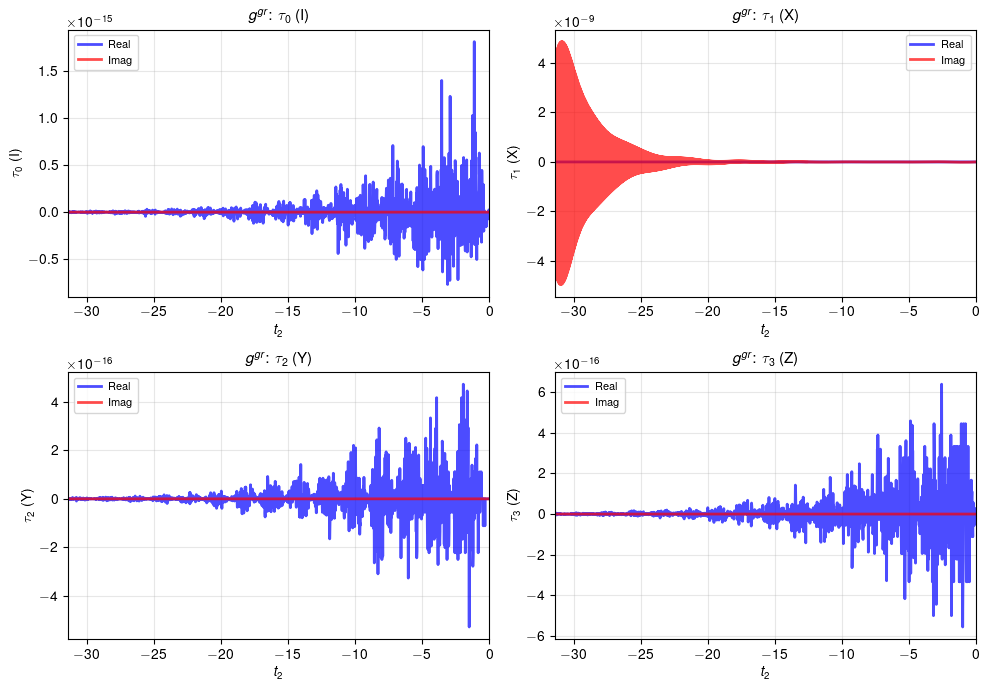

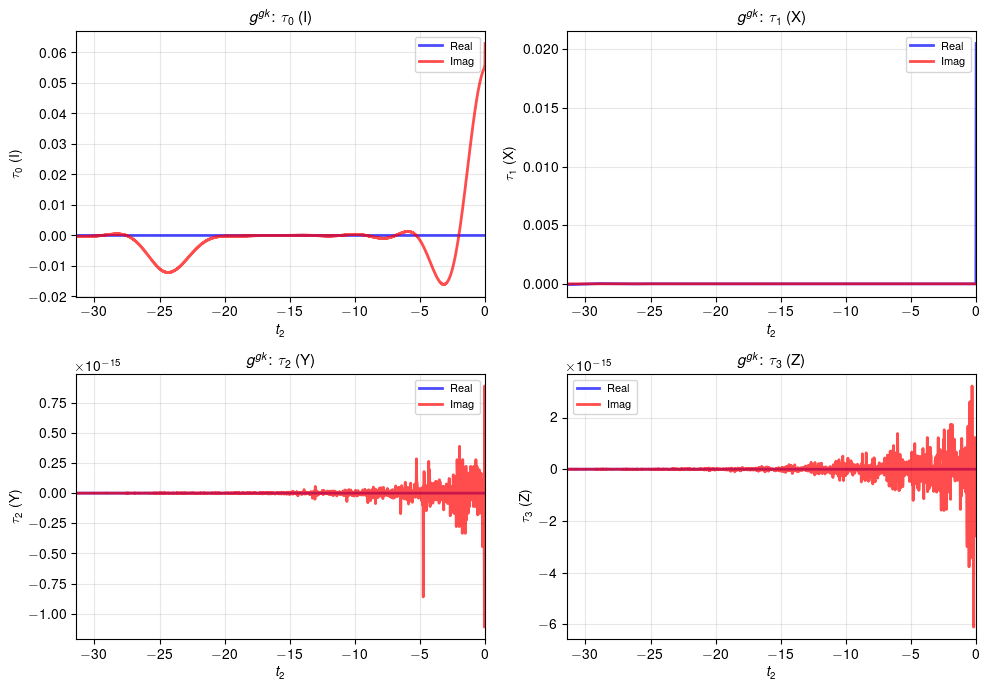


Normalization Check Results:
  gr errors per channel:
    τ₀: 1.00e+00
    τ₁: 4.95e-09
    τ₂: 5.27e-16
    τ₃: 6.38e-16
  gr max error: 1.00e+00 (in channel τ₀)

  gk errors per channel:
    τ₀: 6.29e-02
    τ₁: 2.05e-02
    τ₂: 1.11e-15
    τ₃: 6.11e-15
  gk max error: 6.29e-02 (in channel τ₀)


In [28]:
# Check gr and gk normalization relations
norm_results = da.check_normalizations(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']

print(f"\nNormalization Check Results:")
print(f"  gr errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gr_max_error'][i]:.2e}")
gr_max_idx = np.argmax(norm_results['gr_max_error'])
print(f"  gr max error: {norm_results['gr_max_error'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gk_max_error'][i]:.2e}")
gk_max_idx = np.argmax(norm_results['gk_max_error'])
print(f"  gk max error: {norm_results['gk_max_error'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")

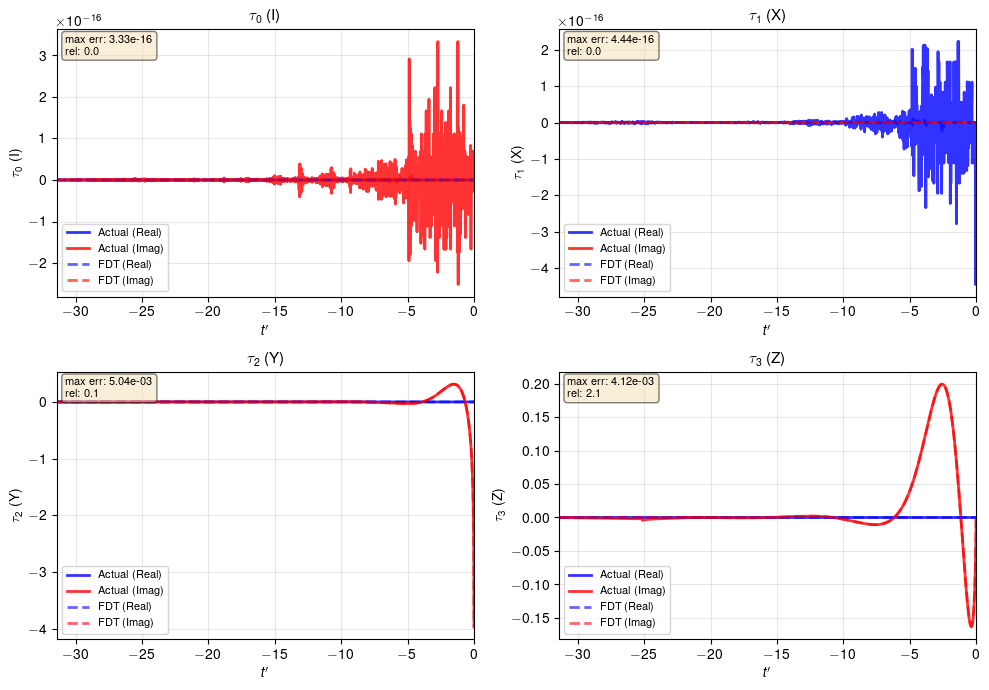


FDT Check Results:
  Errors per channel:
    τ₀: 3.33e-16
    τ₁: 4.44e-16
    τ₂: 5.04e-03
    τ₃: 4.12e-03
  Max error: 5.04e-03 (in channel τ₂)


In [33]:
# Check fluctuation-dissipation theorem
fdt_results = da.check_fdt(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nFDT Check Results:")
print(f"  Errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {fdt_results['max_error'][i]:.2e}")
max_idx = np.argmax(fdt_results['max_error'])
print(f"  Max error: {fdt_results['max_error'][max_idx]:.2e} (in channel {pauli_names[max_idx]})")

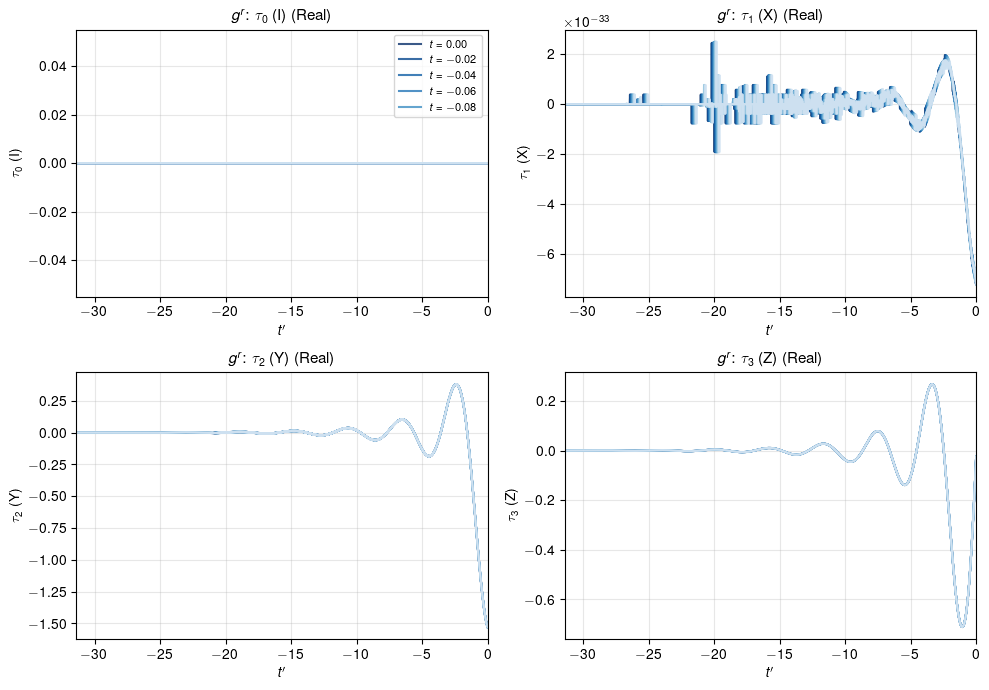

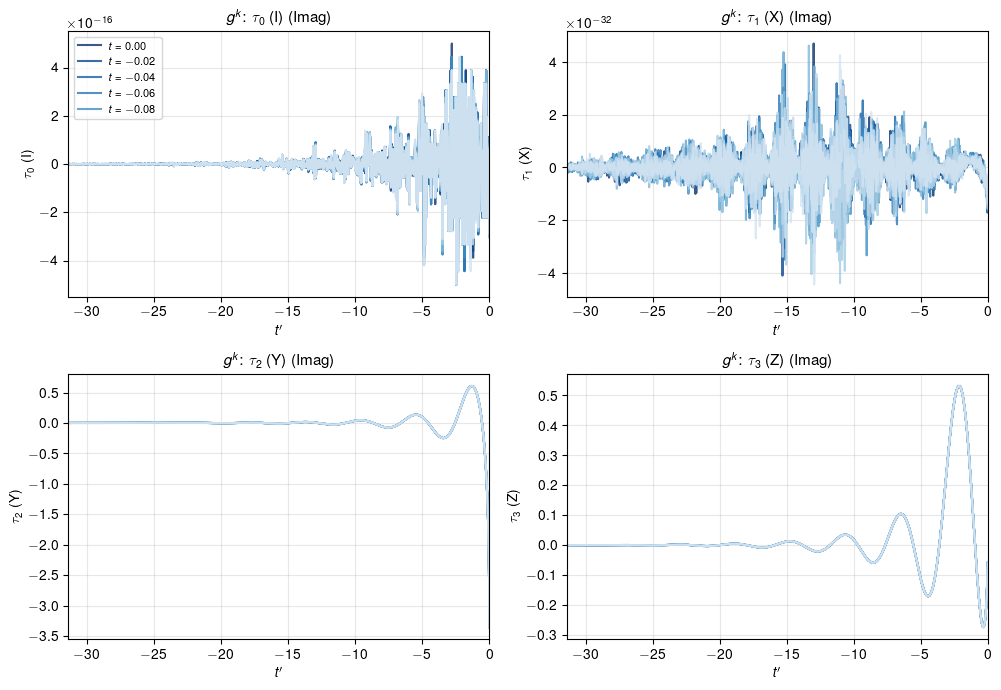


Time-Translation Invariance Results:
  gr max diffs per row: [0.0, np.float64(1.5373733657772952), np.float64(1.5373733657772952), np.float64(1.5373733657772952), np.float64(1.5373733657772952), np.float64(1.5373733657772952), np.float64(1.5373733657772952), np.float64(1.5373733657772952), np.float64(1.5373733657772952), np.float64(1.5373733657772952)]
  gr max diff: 1.54e+00 (in row 2 from last)

  gk max diffs per row: [0.0, np.float64(5.026337079709098), np.float64(5.026337079709098), np.float64(5.026337079709098), np.float64(5.026337079709098), np.float64(5.026337079709098), np.float64(5.026337079709098), np.float64(5.026337079709098), np.float64(5.026337079709098), np.float64(5.026337079709098)]
  gk max diff: 5.03e+00 (in row 2 from last)

  Passed (threshold 1e-08): False


In [52]:
# Check time-translation invariance (equilibrium test)
tti_results = da.check_time_translational_invariance(check_timestamp, check_job_index,
                                                      num_rows=10, threshold=1e-8, save_plot=False)

print(f"\nTime-Translation Invariance Results:")
print(f"  gr max diffs per row: {tti_results['max_diff_gr']}")
gr_max_idx = np.argmax(tti_results['max_diff_gr'])
print(f"  gr max diff: {tti_results['max_diff_gr'][gr_max_idx]:.2e} (in row {gr_max_idx + 1} from last)")

print(f"\n  gk max diffs per row: {tti_results['max_diff_gk']}")
gk_max_idx = np.argmax(tti_results['max_diff_gk'])
print(f"  gk max diff: {tti_results['max_diff_gk'][gk_max_idx]:.2e} (in row {gk_max_idx + 1} from last)")

print(f"\n  Passed (threshold {tti_results['threshold']:.0e}): {tti_results['passed']}")

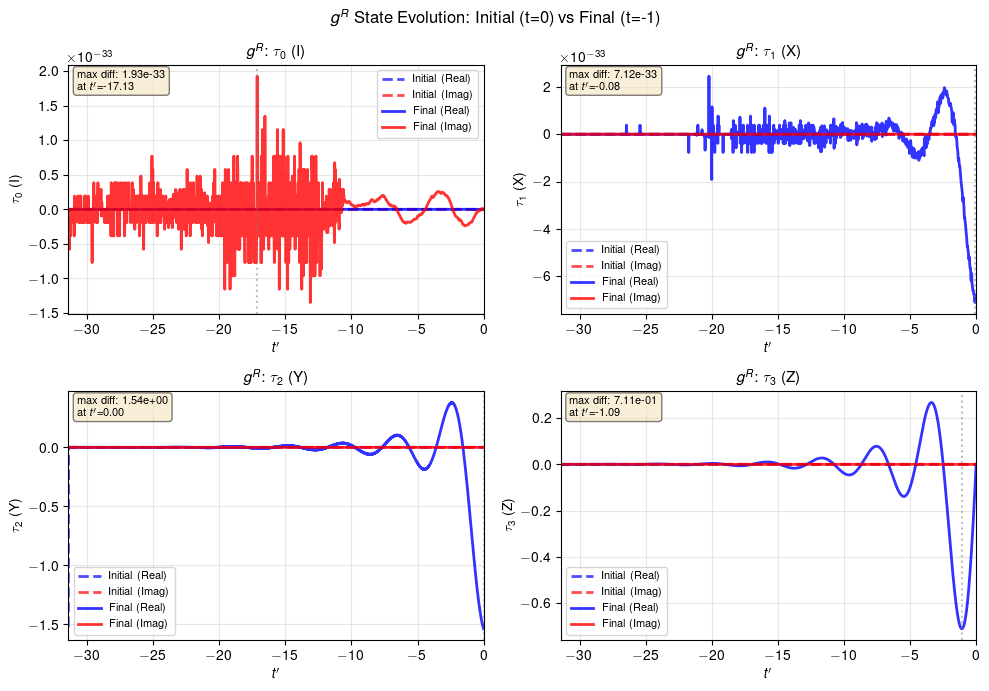

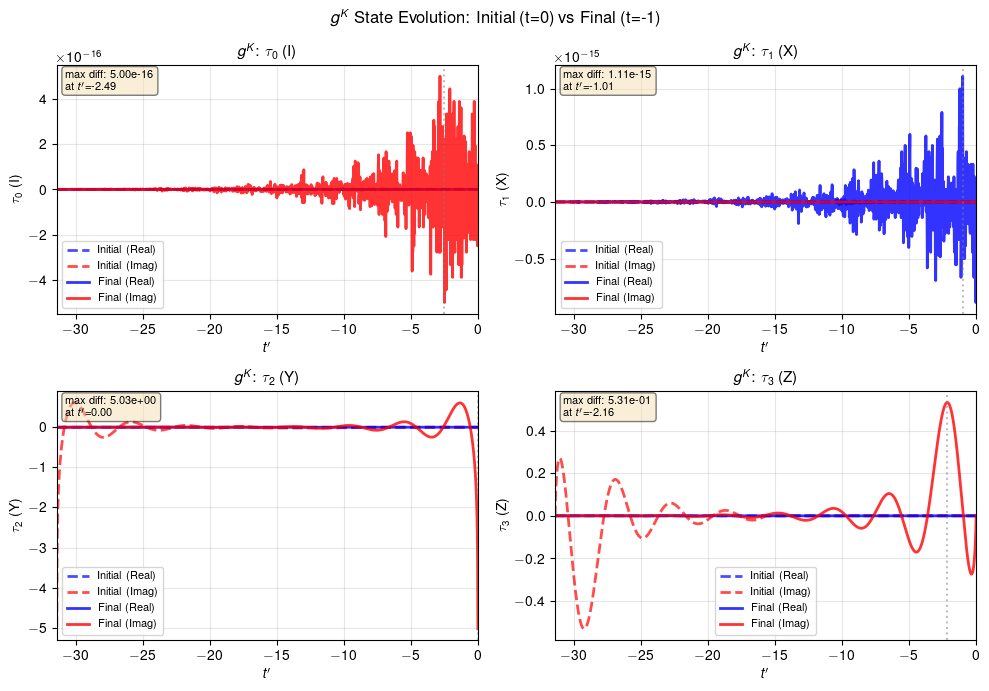


State Evolution Check Results:
  gr differences per channel (initial t=0 vs final t=-1):
    τ₀: 1.93e-33
    τ₁: 7.12e-33
    τ₂: 1.54e+00
    τ₃: 7.11e-01
  gr max diff: 1.54e+00 (in channel τ₂)

  gk differences per channel (initial t=0 vs final t=-1):
    τ₀: 5.00e-16
    τ₁: 1.11e-15
    τ₂: 5.03e+00
    τ₃: 5.31e-01
  gk max diff: 5.03e+00 (in channel τ₂)


In [53]:
# Check state evolution (initial vs final time)
evolution_results = da.check_state_evolution(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nState Evolution Check Results:")
print(f"  gr differences per channel (initial t=0 vs final t=-1):")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {evolution_results['gr_max_diff'][i]:.2e}")
gr_max_idx = np.argmax(evolution_results['gr_max_diff'])
print(f"  gr max diff: {evolution_results['gr_max_diff'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk differences per channel (initial t=0 vs final t=-1):")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {evolution_results['gk_max_diff'][i]:.2e}")
gk_max_idx = np.argmax(evolution_results['gk_max_diff'])
print(f"  gk max diff: {evolution_results['gk_max_diff'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")

# 2. Gap and Current Analysis


Input Parameters (timestamp=1780846595, job_index=0):
  num_timesteps: 300
  system_parameters: {'critical_temperature': 1, 'temperature': 0.3, 'eta': 0.2}
  initial_state_timestamp: None
  initial_state_index: 0
  grid_parameters: {'time_sampling': 1501, 'time_duration': 31.41592653589793}
  driving_field: [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 

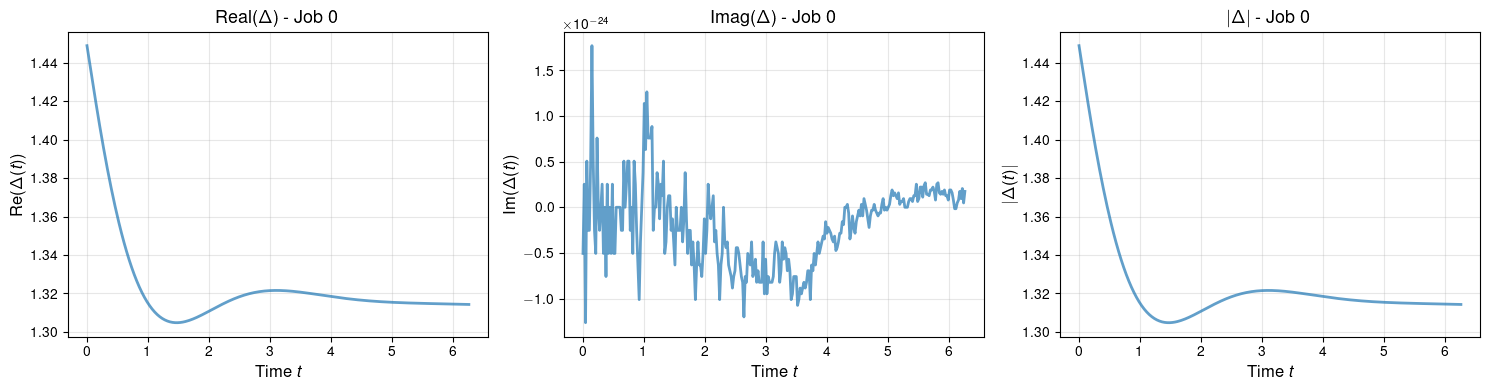

In [62]:
# Plot gap evolution for this job
da.plot_gap(check_timestamp, check_job_index, save_plot=False)


Input Parameters (timestamp=1780846595, job_index=0):
  num_timesteps: 300
  system_parameters: {'critical_temperature': 1, 'temperature': 0.3, 'eta': 0.2}
  initial_state_timestamp: None
  initial_state_index: 0
  grid_parameters: {'time_sampling': 1501, 'time_duration': 31.41592653589793}
  driving_field: [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 

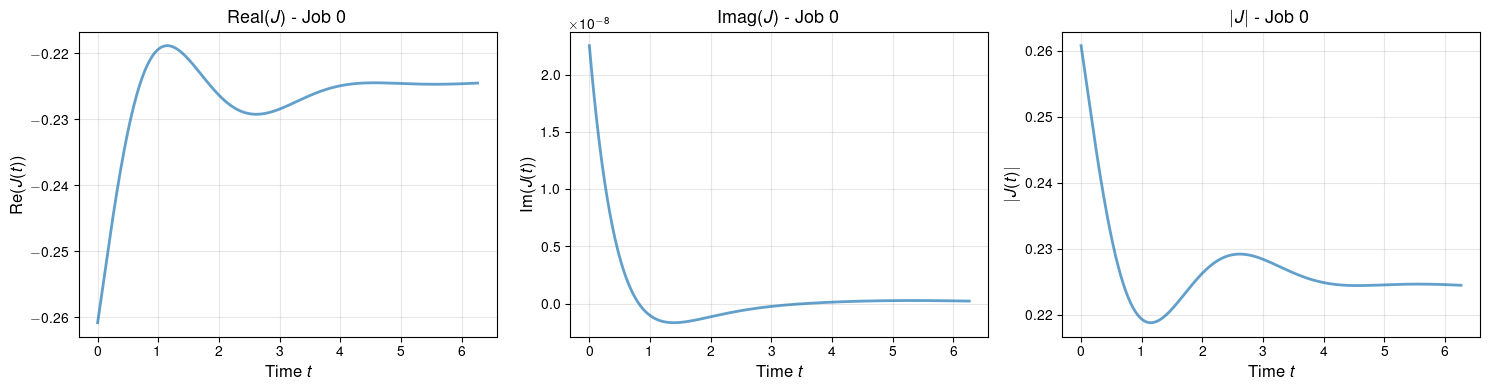

In [37]:
# Plot current evolution for this job
da.plot_current(check_timestamp, check_job_index, save_plot=False)

# 3. Parameter Sweep Analysis

Run this section to compare equilibrated gap/current across multiple timestamps.

In [14]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1780988799']  # Add more timestamps as needed: ['ts1', 'ts2', ...]

# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'temperature'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: temperature
Timestamps to analyze: ['1780988799']
Averaging last 100 timesteps


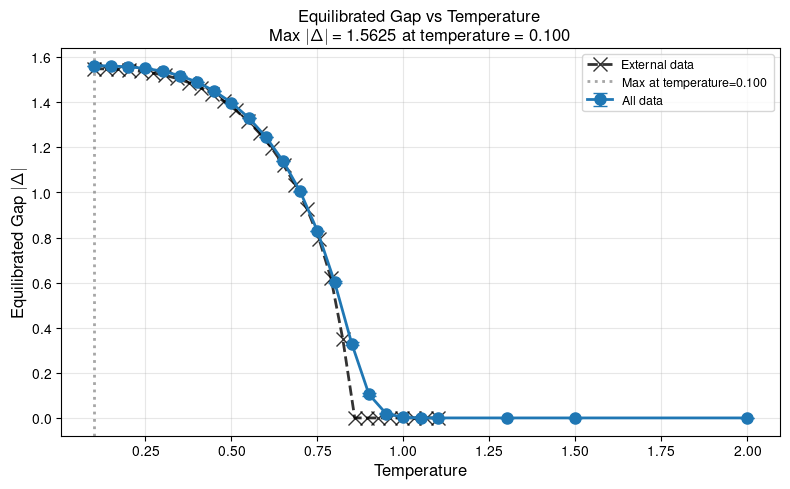


Gap Sweep Results:
  Parameter values: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.3  1.5  2.  ]
  Gap means: [ 1.56254486e+00+1.32947211e-32j  1.56063213e+00+9.66192254e-33j
  1.55701538e+00+8.40404488e-33j  1.55002774e+00+1.00773938e-32j
  1.53770507e+00+1.25092661e-32j  1.51812789e+00+8.05432888e-33j
  1.48952571e+00+7.85354248e-33j  1.45017784e+00+7.12082787e-33j
  1.39822599e+00+1.05407088e-32j  1.33142374e+00+1.24848011e-32j
  1.24677747e+00+8.64277586e-33j  1.13997247e+00+7.27405585e-33j
  1.00440746e+00+8.93663118e-33j  8.29827303e-01+9.26507152e-33j
  6.03046256e-01+5.94724515e-33j  3.29531833e-01+3.21994823e-33j
  1.04655705e-01+1.33718333e-33j  1.88594971e-02+3.06250009e-34j
  2.39810830e-03+7.26749808e-35j  2.48982523e-04+1.29787891e-35j
  2.23523981e-05+4.24543960e-36j  1.02610616e-07+3.43352906e-37j
  2.13467407e-08-1.01007452e-38j -1.82781036e-09+3.98887029e-39j]
  Gap errors: [3.13636115e-07 4.84731106e-0

In [15]:
# Plot equilibrated gap vs parameter
gap_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps, 
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, combine_timestamps = True,
    x_external = eq_T, y_external = eq_gap_mag_T
)


print(f"\nGap Sweep Results:")
print(f"  Parameter values: {gap_sweep_results['parameter_values']}")
print(f"  Gap means: {gap_sweep_results['gap_means']}")
print(f"  Gap errors: {gap_sweep_results['gap_errors']}")
print(f"\nMaximum Gap:")
print(f"  Max |Δ| = {gap_sweep_results['max_gap']:.4f}")
print(f"  At {sweep_parameter} = {gap_sweep_results['max_parameter']:.4f}")

In [16]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1780988780']  # Add more timestamps as needed: ['ts1', 'ts2', ...]

# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'vector_potential'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: vector_potential
Timestamps to analyze: ['1780988780']
Averaging last 100 timesteps


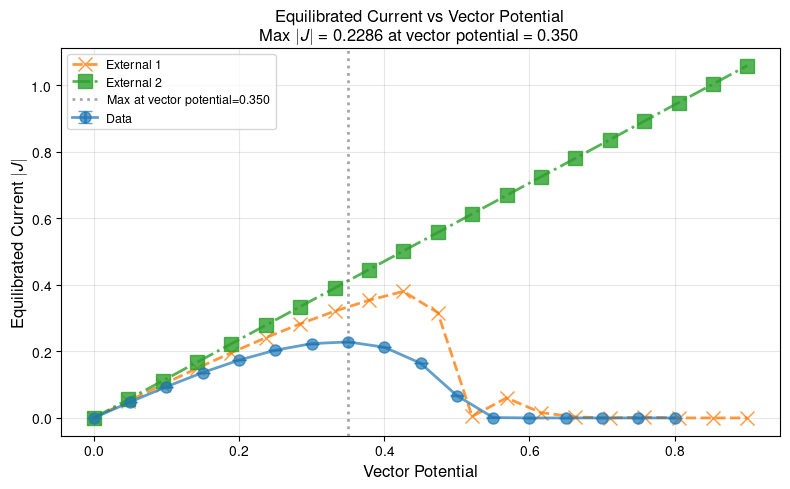


Current Sweep Results:
  Parameter values: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8 ]
  Current means: [ 0.00000000e+00+0.00000000e+00j -4.77654257e-02-4.31231372e-23j
 -9.38467120e-02+1.57932771e-22j -1.36484228e-01+2.14312307e-23j
 -1.73806062e-01+2.75609930e-22j -2.03692183e-01-2.87764287e-22j
 -2.23381994e-01+1.39367582e-21j -2.28579276e-01-9.15978266e-22j
 -2.12786766e-01-2.60905624e-22j -1.64544092e-01+2.63966569e-21j
 -6.71645355e-02-9.48818424e-22j -1.14530922e-03+3.38318659e-22j
 -1.98607087e-06+2.27830911e-22j -3.24580871e-07+1.28431808e-22j
 -9.61375667e-08+6.35241619e-23j -2.81327907e-08+2.86614669e-23j
 -8.19624125e-09+1.20987165e-23j]
  Current errors: [0.00000000e+00 1.84464827e-07 1.00921277e-06 3.62068207e-07
 6.32223047e-06 1.98601569e-06 7.00671839e-06 1.57137910e-05
 2.43404822e-05 6.61551453e-05 4.22350443e-04 1.60359485e-04
 3.29116692e-07 7.48163663e-09 4.52238517e-09 2.65029855e-09
 1.54918751e-09]

Maximum Current:


In [17]:
# Plot equilibrated current vs parameter

current_sweep_results = da.plot_equilibrated_current_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A,eq_A], y_external = [eq_current_A/4, eq_A * np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.3)/4]
)
#* added 1/2 factor for comparison since original current heory was wrong so to rescale. -- fixed in new version 


print(f"\nCurrent Sweep Results:")
print(f"  Parameter values: {current_sweep_results['parameter_values']}")
print(f"  Current means: {current_sweep_results['current_means']}")
print(f"  Current errors: {current_sweep_results['current_errors']}")
print(f"\nMaximum Current:")
print(f"  Max |J| = {current_sweep_results['max_current']:.4f}")
print(f"  At {sweep_parameter} = {current_sweep_results['max_parameter']:.4f}")

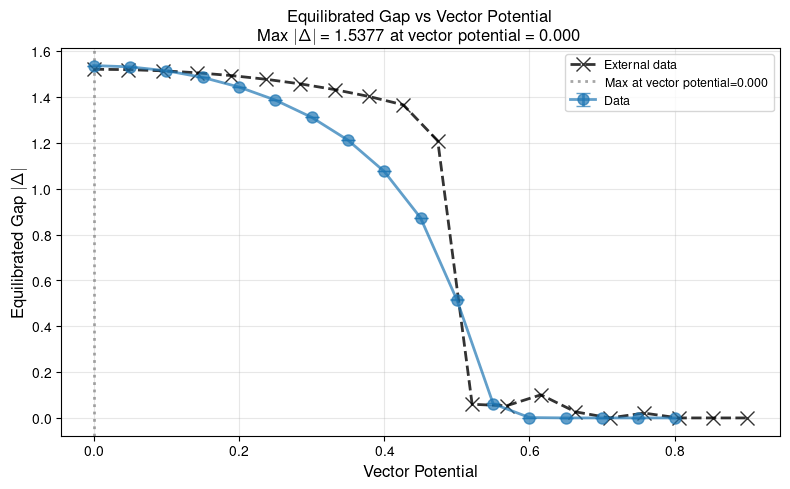

In [21]:

# Plot equilibrated current vs parameter
current_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = eq_A, y_external = eq_gap_mag_A
)


